# Double Exponential ON cell model (withdrawal aligned)

The models in this notebook will fit to the entirety of the trial activity of the ON cells (pre and post) simultaneously.

In [1]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2

import os
import json
import arviz as az
import numpy as np
from pathlib import Path
from quantities import s
import matplotlib.pyplot as plt
from pymc import model_to_graphviz


from rvm_analysis.utils import combine_datasets_into_data_manager
from rvm_analysis.utils import import_on_off_trials, import_extra_cells
from rvm_analysis.trial_analysis_functions import create_trial_df
from rvm_analysis.bayesian_cell_models import build_double_exponential_on_model, store_model_predictions
from rvm_analysis.bayesian_cell_models import plot_prior_predictive_checks
from rvm_analysis.bayesian_cell_models import calculate_rate_percentages_of_peak,create_X_and_Y_training_data
from rvm_analysis.bayesian_cell_models import sample_model,compute_and_save_log_likelihood,compute_predictions_over_new_data
from rvm_analysis.plotting import plot_predictions_paper
from rvm_analysis.data_loaders import read_dataset_by_protocol



#! Force the backend back to matplotlib inline (after importing viziphant).
%matplotlib inline
print(plt.get_backend())

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
c:\Users\carla\Documents\Cambridge\PhD\Paper_1\Publication_Code\Multi-timescale-Rhythmic-Dynamics-in-RVM-neurons\env\lib\site-packages\holoviews\util\parser.py:152: PyparsingDeprecationWarning: 'nestedExpr' deprecated - use 'nested_expr'
  plot_options_short = pp.nestedExpr('[',
c:\Users\carla\Documents\Cambridge\PhD\Paper_1\Publication_Code\Multi-timescale-Rhythmic-Dynamics-in-RVM-neurons\env\lib\site-packages\holoviews\util\parser.py:152: PyparsingDeprecationWarning: 'setResultsName' deprecated - use 'set_results_name'
  plot_options_short = pp.nestedExpr('[',
c:\Users\carla\Documents\Cambridge\PhD\Paper_1\Publication_Code\Multi-timescale-Rhythmic-Dynamics-in-RVM-neurons\env\lib\site-packages\pyparsing\util.py:477: PyparsingDeprecationWarning: 'ignoreExpr' argument is deprecated, use 'ignore_expr'
  return fn(*args, **kwargs)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

module://matplotlib_inline.backend_inline


## Import the trial data

In [2]:
base_path: Path = Path("./models/on_models/18_double_exponential_aggregated_counts/")
model_name ="on_trial_model.nc"
full_path = base_path / model_name
parameter_dictionary = base_path / "param_dict.json"

with open(parameter_dictionary,"r") as f:
    p: dict = json.load(f)


p['PRIORS']['LOG_K_PRE']['MU'] = 4
p['PRIORS']['LOG_K_PRE']['SIGMA'] = 0.1

p['PRIORS']['LOG_BASE_RATE_PRE']['MU'] = 3
p['PRIORS']['LOG_BASE_RATE_PRE']['SIGMA'] = 0.5
p['PRIORS']['LOG_BASE_RATE_POST']['MU'] = 3
p['PRIORS']['LOG_BASE_RATE_POST']['SIGMA'] = 0.5

p['PRIORS']['LOG_K_POST'] = {
'MU': 2.5,
'SIGMA': 1
}

p['PRIORS']['SIGMA_BASE_RATE_POST'] = 1

p

{'POST_EVENT_PERIOD': 100,
 'PRE_EVENT_PERIOD': -10,
 'SKIP': 1,
 'DRAWS': 1000,
 'TUNE': 1000,
 'BIN_SIZE': 0.05,
 'PRIORS': {'T_LOWER': -4,
  'T_UPPER': 4,
  'SIGMA_BASE_RATE': 5,
  'LOG_BASE_RATE_PRE': {'MU': 3, 'SIGMA': 0.5},
  'LOG_BASE_RATE_POST': {'MU': 3, 'SIGMA': 0.5},
  'LOG_K_PRE': {'MU': 4, 'SIGMA': 0.1},
  'LOG_K_POST': {'MU': 2.5, 'SIGMA': 1},
  'SIGMA_BASE_RATE_POST': 1}}

In [3]:
def print_raw_priors(p):
    print(p['PRIORS'][''])

In [4]:
def deprecated_spike_2_imports():
    """
    Data imports, deprecated in favour of importing directly from NWB.
    """
    dm1 = import_on_off_trials()
    dm2 = import_extra_cells()
    dm = combine_datasets_into_data_manager(dm1,dm2)
    return dm

dm = read_dataset_by_protocol(['evoked','ongoing','evoked/ongoing'])

Found 101 blocks from 101 NWB files.
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus03_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus23_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus25_CA2.smrx
['EKG', 'paw_withdrawal', 'heat', 'pinch']
['EKG', 'flick', 'heat', 'keyboard']
LHb_Mus28_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic04_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic05_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic07_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic16_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic20_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic27_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic36_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus06_CA2.smrx
['EKG'

In [5]:
for block in dm.blocks:
    print([sp.file_origin for sp in block.segments[0].spiketrains])

[WindowsPath('LHb_Mus03_CA3.smrx'), WindowsPath('LHb_Mus03_CA3.smrx'), WindowsPath('LHb_Mus03_CA3.smrx')]
[WindowsPath('LHb_Mus23_CA2.smrx'), WindowsPath('LHb_Mus23_CA2.smrx')]
[WindowsPath('LHb_Mus25_CA2.smrx'), WindowsPath('LHb_Mus25_CA2.smrx')]
[WindowsPath('LHb_Mus28_CA2.smrx'), WindowsPath('LHb_Mus28_CA2.smrx')]
[WindowsPath('LHb_Bic04_CA3.smrx'), WindowsPath('LHb_Bic04_CA3.smrx'), WindowsPath('LHb_Bic04_CA3.smrx')]
[WindowsPath('LHb_Bic05_CA3.smrx'), WindowsPath('LHb_Bic05_CA3.smrx'), WindowsPath('LHb_Bic05_CA3.smrx')]
[WindowsPath('LHb_Bic07_CA3.smrx'), WindowsPath('LHb_Bic07_CA3.smrx'), WindowsPath('LHb_Bic07_CA3.smrx')]
[WindowsPath('LHb_Bic16_CA2.smrx'), WindowsPath('LHb_Bic16_CA2.smrx')]
[WindowsPath('LHb_Bic20_CA3.smrx'), WindowsPath('LHb_Bic20_CA3.smrx'), WindowsPath('LHb_Bic20_CA3.smrx')]
[WindowsPath('LHb_Bic27_CA2.smrx'), WindowsPath('LHb_Bic27_CA2.smrx')]
[WindowsPath('LHb_Bic36_CA2.smrx'), WindowsPath('LHb_Bic36_CA2.smrx')]
[WindowsPath('LHb_Mus06_CA2.smrx'), WindowsP

In [6]:
on_flick_list, on_flick_list_by_cell = dm.plot_spikes_around_event("flick",p["PRE_EVENT_PERIOD"] * s,p["POST_EVENT_PERIOD"] * s,
                                                                             cell_type='ON',sorted_by=None,color_by_file=False,
                                                                             save=None,plot=False)

print(len(on_flick_list))

Next event [end,960.6372463999999 s] cuts off window
Next event [end,960.6323349999999 s] cuts off window
Next event [end,960.5768977999999 s] cuts off window
Next event [end,960.5768977999999 s] cuts off window
Next event [end,961.3760155999998 s] cuts off window
Next event [end,961.3760155999998 s] cuts off window
Next event [end,961.3760155999998 s] cuts off window
Next event [end,960.7673893999998 s] cuts off window
Next event [end,960.7673893999998 s] cuts off window
Next event [end,960.7673893999998 s] cuts off window
Next event [end,962.3898569999999 s] cuts off window
Next event [end,962.3898569999999 s] cuts off window
No corresponding flick, missing trains [20, 21, 22], event 4
No corresponding flick, missing trains [20, 21, 22], event 4
No corresponding flick, missing trains [20, 21, 22], event 4
Next event [end,961.8416963999999 s] cuts off window
Next event [end,964.4771317999998 s] cuts off window
Next event [end,964.4771317999998 s] cuts off window
Next event [end,960.67

,index,animal,cell,trial,time,count
0,0,LHb_Mus03_CA3.smrx,0,0,-10.00,0
1,1,LHb_Mus03_CA3.smrx,0,0,-9.95,0
2,2,LHb_Mus03_CA3.smrx,0,0,-9.90,0
3,3,LHb_Mus03_CA3.smrx,0,0,-9.85,0
4,4,LHb_Mus03_CA3.smrx,0,0,-9.80,0
...,...,...,...,...,...,...
428995,428995,LHb_Mus16_CA2.smrx,69,1,99.75,0
428996,428996,LHb_Mus16_CA2.smrx,69,1,99.80,0
428997,428997,LHb_Mus16_CA2.smrx,69,1,99.85,0
428998,428998,LHb_Mus16_CA2.smrx,69,1,99.90,0


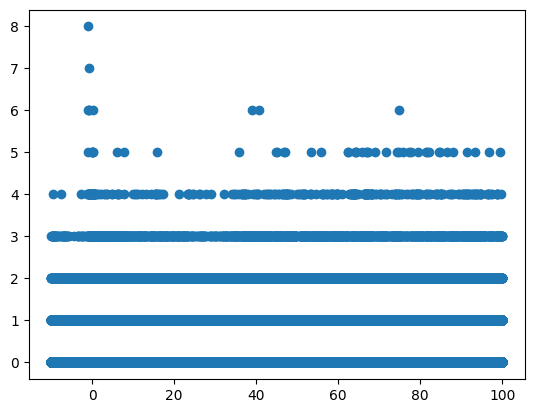

       time  count
0    -10.00     33
1     -9.95     26
2     -9.90     27
3     -9.85     26
4     -9.80     31
...     ...    ...
2195  99.75     56
2196  99.80     59
2197  99.85     46
2198  99.90     62
2199  99.95     53

[2200 rows x 2 columns]


In [7]:
df = create_trial_df(p["BIN_SIZE"] * s,on_flick_list_by_cell)
display(df)

# Plot the raw count data
plt.scatter(df['time'],df['count'])
plt.show()

counts = df.groupby('time',as_index=False)['count'].sum()
print(counts)

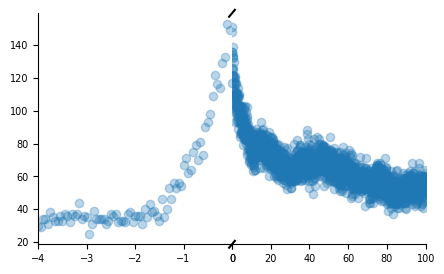

In [8]:
X_data,Y_data = create_X_and_Y_training_data(counts,skip=1,plot=True)

## Model definitinon

In [9]:
from rvm_analysis.bayesian_cell_models import build_double_exponential_on_model_reversed_sampling


on_model = build_double_exponential_on_model(X_data,Y_data,p)

## Vizualise the model

In [10]:
# model_to_graphviz(on_model,save=os.path.join(base_path,"graph.png"))

## Prior predictive checks

Sampling: [beta_1_post, beta_1_pre, beta_slow_post, log_base_rate_post, log_base_rate_pre, log_k_post, log_k_pre, t_switch]
[distfit] >INFO> Sampling: [beta_1_post, beta_1_pre, beta_slow_post, log_base_rate_post, log_base_rate_pre, log_k_post, log_k_pre, t_switch]


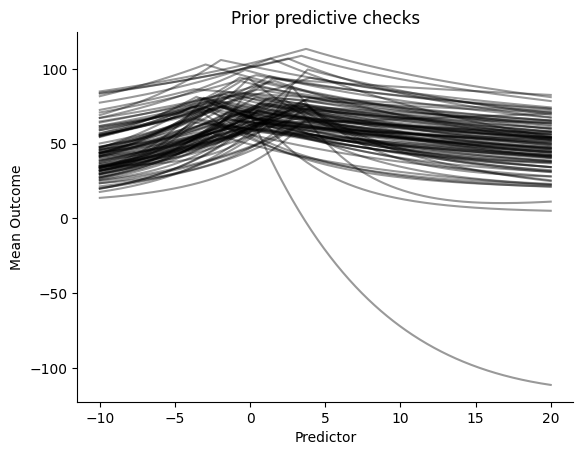

In [11]:
X_test = np.linspace(-10,20,500)
plot_prior_predictive_checks(on_model,X_test,n_sample_paths=100)

## Sample from the model

We sample from the model, and save the results. If the model has already been sampled from, then we generate the derived quantities for use in the plotting and later analysis.

In [12]:
SAMPLE = True

idata = sample_model(on_model,X_data,full_path,p,sample=SAMPLE,chains=4,
                     target_accept=0.8) # 0.8 is the default


Auto-assigning NUTS sampler...
[distfit] >INFO> Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
[distfit] >INFO> Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
[distfit] >INFO> Multiprocess sampling (4 chains in 4 jobs)
NUTS: [t_switch, log_base_rate_pre, log_base_rate_post, beta_1_pre, beta_1_post, beta_slow_post, log_k_pre, log_k_post]
[distfit] >INFO> NUTS: [t_switch, log_base_rate_pre, log_base_rate_post, beta_1_pre, beta_1_post, beta_slow_post, log_k_pre, log_k_post]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 253 seconds.
[distfit] >INFO> Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 253 seconds.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
[distfit] >ERROR> There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 220 seconds.
[distfit] >INFO> Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 220 seconds.
There were 29 divergences after tuning. Increase `target_accept` or reparameterize.
[distfit] >ERROR> There were 29 divergences after tuning. Increase `target_accept` or reparameterize.

In [13]:

# # Calculate tau values and exponentiated HDIs
posterior = idata.posterior
derived_params = {
"tau_pre": 1/posterior['beta_1_pre'],
"tau_post_slow": 1/posterior['beta_slow_post'],
"tau_post_fast": 1/posterior['beta_1_post'],

"r_pre": np.exp(posterior['log_base_rate_pre']),
"r_post": np.exp(posterior['log_base_rate_post']),

"k_post": np.exp(posterior['log_k_post']),
"k_pre": np.exp(posterior['log_k_pre']),
"posterior_rate_diff": np.exp(posterior['log_base_rate_pre']) - np.exp(posterior['log_base_rate_post']),
}

idata.posterior = idata.posterior.assign(**derived_params)

In [14]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [15]:
var_names = ["r_post","r_pre","k_post",
 "k_slow","tau_post_slow","t_switch","k_pre","tau_post_fast","tau_pre","posterior_rate_diff"]

## Compute the model log likelihood and save

In [16]:
COMPUTE_LL = True
loglik_save_path = base_path / "idata_with_log_liks.nc" 

compute_and_save_log_likelihood(on_model,idata,save_path=loglik_save_path,recompute=COMPUTE_LL)

Computed from 4000 posterior samples and 2200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -7215.49    20.13
p_loo        4.44        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     2200  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



## Summarize the model

In [17]:
# Print a summary of the model parameters
summary = az.summary(idata,var_names=var_names)

display(summary)

summary.to_latex(os.path.join(base_path,"posterior_table_ON_flick_double_exp.tex"),index=True, escape=True,
                 float_format="%.3f")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r_post,16.002,5.129,6.475,25.429,0.112,0.081,2148.0,2205.0,1.0
r_pre,30.685,0.473,29.822,31.574,0.009,0.006,3085.0,2544.0,1.0
k_post,50.007,2.232,45.764,54.248,0.054,0.039,1691.0,2041.0,1.0
k_slow,64.386,4.881,54.621,72.667,0.104,0.074,2234.0,2297.0,1.0
tau_post_slow,164.223,18.883,129.571,199.809,0.417,0.295,2089.0,2168.0,1.0
t_switch,-0.184,0.039,-0.257,-0.108,0.001,0.001,2393.0,2311.0,1.0
k_pre,99.711,2.318,95.487,104.250,0.058,0.041,1586.0,1807.0,1.0
tau_post_fast,4.157,0.309,3.582,4.722,0.007,0.005,1905.0,2254.0,1.0
tau_pre,0.653,0.046,0.570,0.739,0.001,0.001,2694.0,2229.0,1.0
posterior_rate_diff,14.682,5.159,4.901,23.911,0.113,0.080,2131.0,2143.0,1.0


array([[<Axes: title={'center': 'r_post'}>,
        <Axes: title={'center': 'r_post'}>],
       [<Axes: title={'center': 'r_pre'}>,
        <Axes: title={'center': 'r_pre'}>],
       [<Axes: title={'center': 'k_post'}>,
        <Axes: title={'center': 'k_post'}>],
       [<Axes: title={'center': 'k_slow'}>,
        <Axes: title={'center': 'k_slow'}>],
       [<Axes: title={'center': 'tau_post_slow'}>,
        <Axes: title={'center': 'tau_post_slow'}>],
       [<Axes: title={'center': 't_switch'}>,
        <Axes: title={'center': 't_switch'}>],
       [<Axes: title={'center': 'k_pre'}>,
        <Axes: title={'center': 'k_pre'}>],
       [<Axes: title={'center': 'tau_post_fast'}>,
        <Axes: title={'center': 'tau_post_fast'}>],
       [<Axes: title={'center': 'tau_pre'}>,
        <Axes: title={'center': 'tau_pre'}>],
       [<Axes: title={'center': 'posterior_rate_diff'}>,
        <Axes: title={'center': 'posterior_rate_diff'}>]], dtype=object)

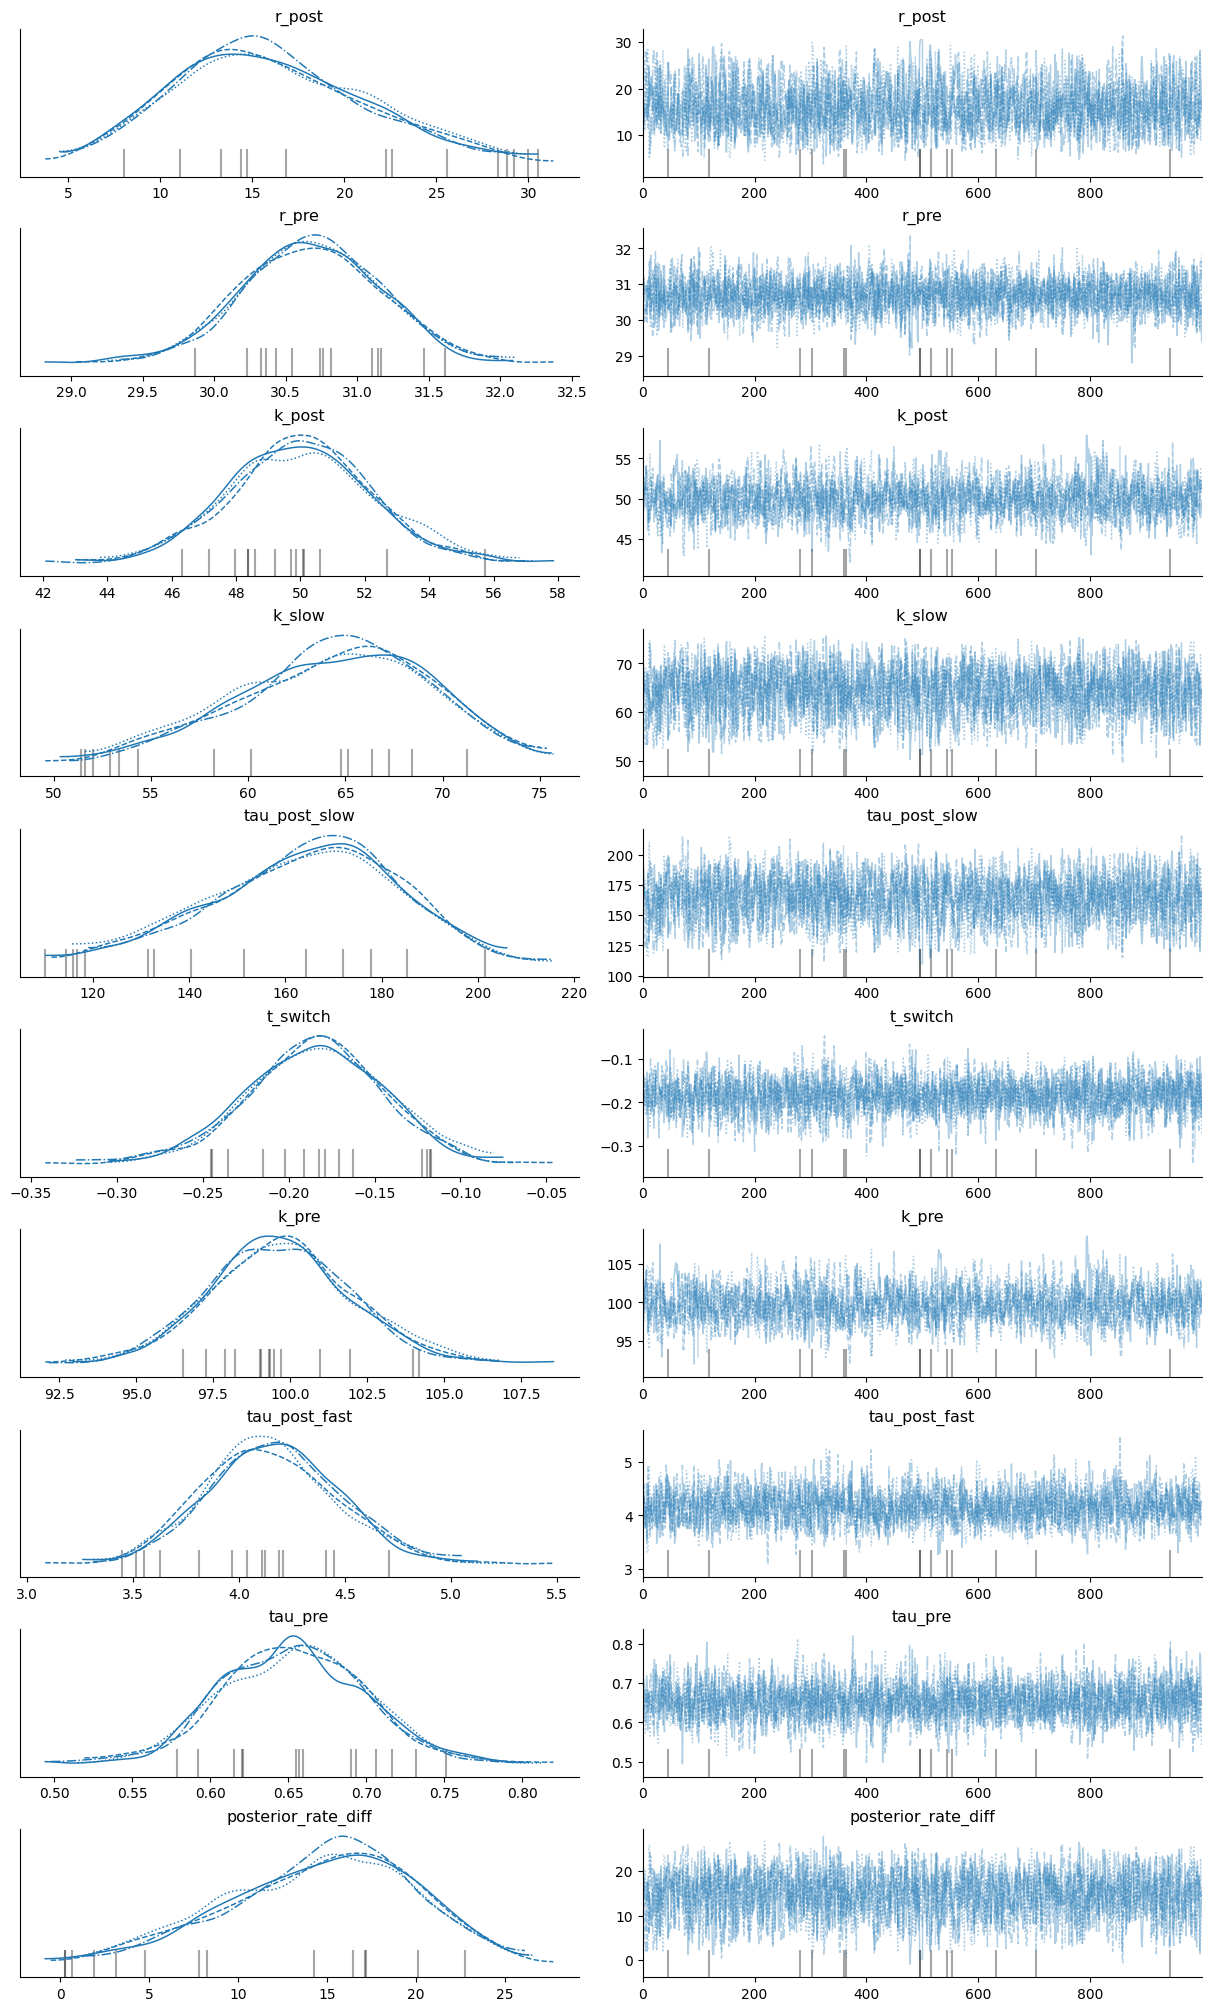

In [18]:
az.plot_trace(idata,backend_kwargs={'layout': 'constrained'},
              var_names=var_names
              )

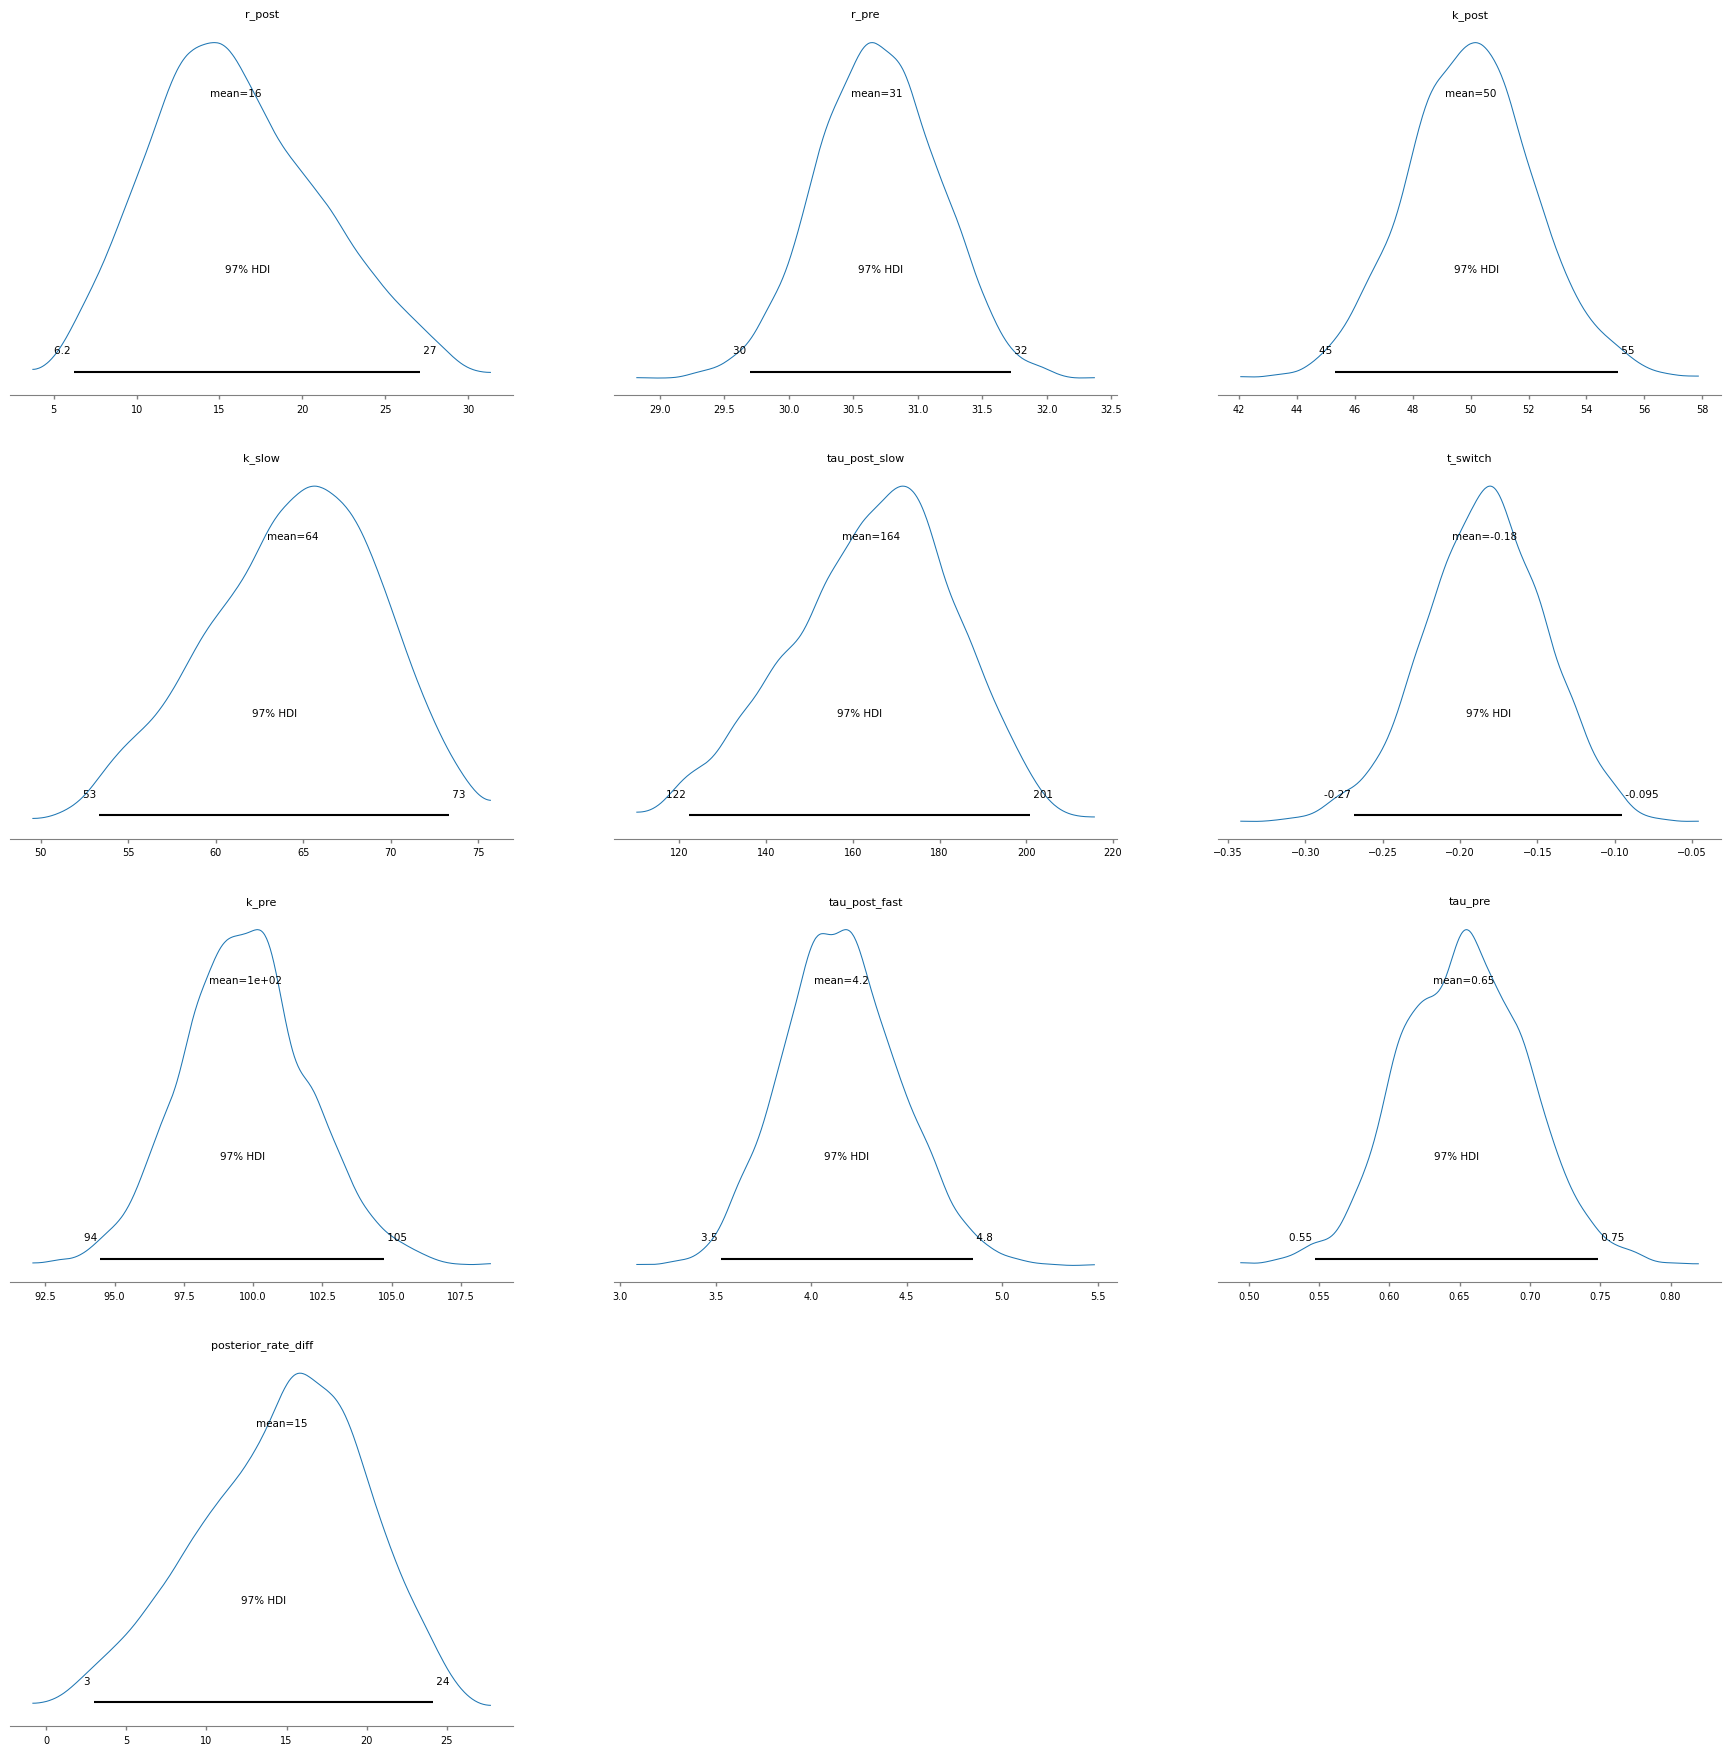

In [19]:
az.plot_posterior(idata, var_names=var_names,textsize=7,hdi_prob=0.97)
plt.show()

## Compute predictions over a set of new input points

In [20]:
X_test = np.linspace(-10,400,20000)

idata_predictions = compute_predictions_over_new_data(on_model,idata,X_test)

Sampling: [count_pred_new]
[distfit] >INFO> Sampling: [count_pred_new]


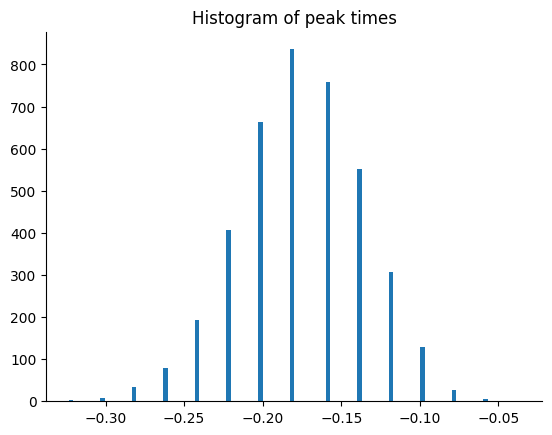

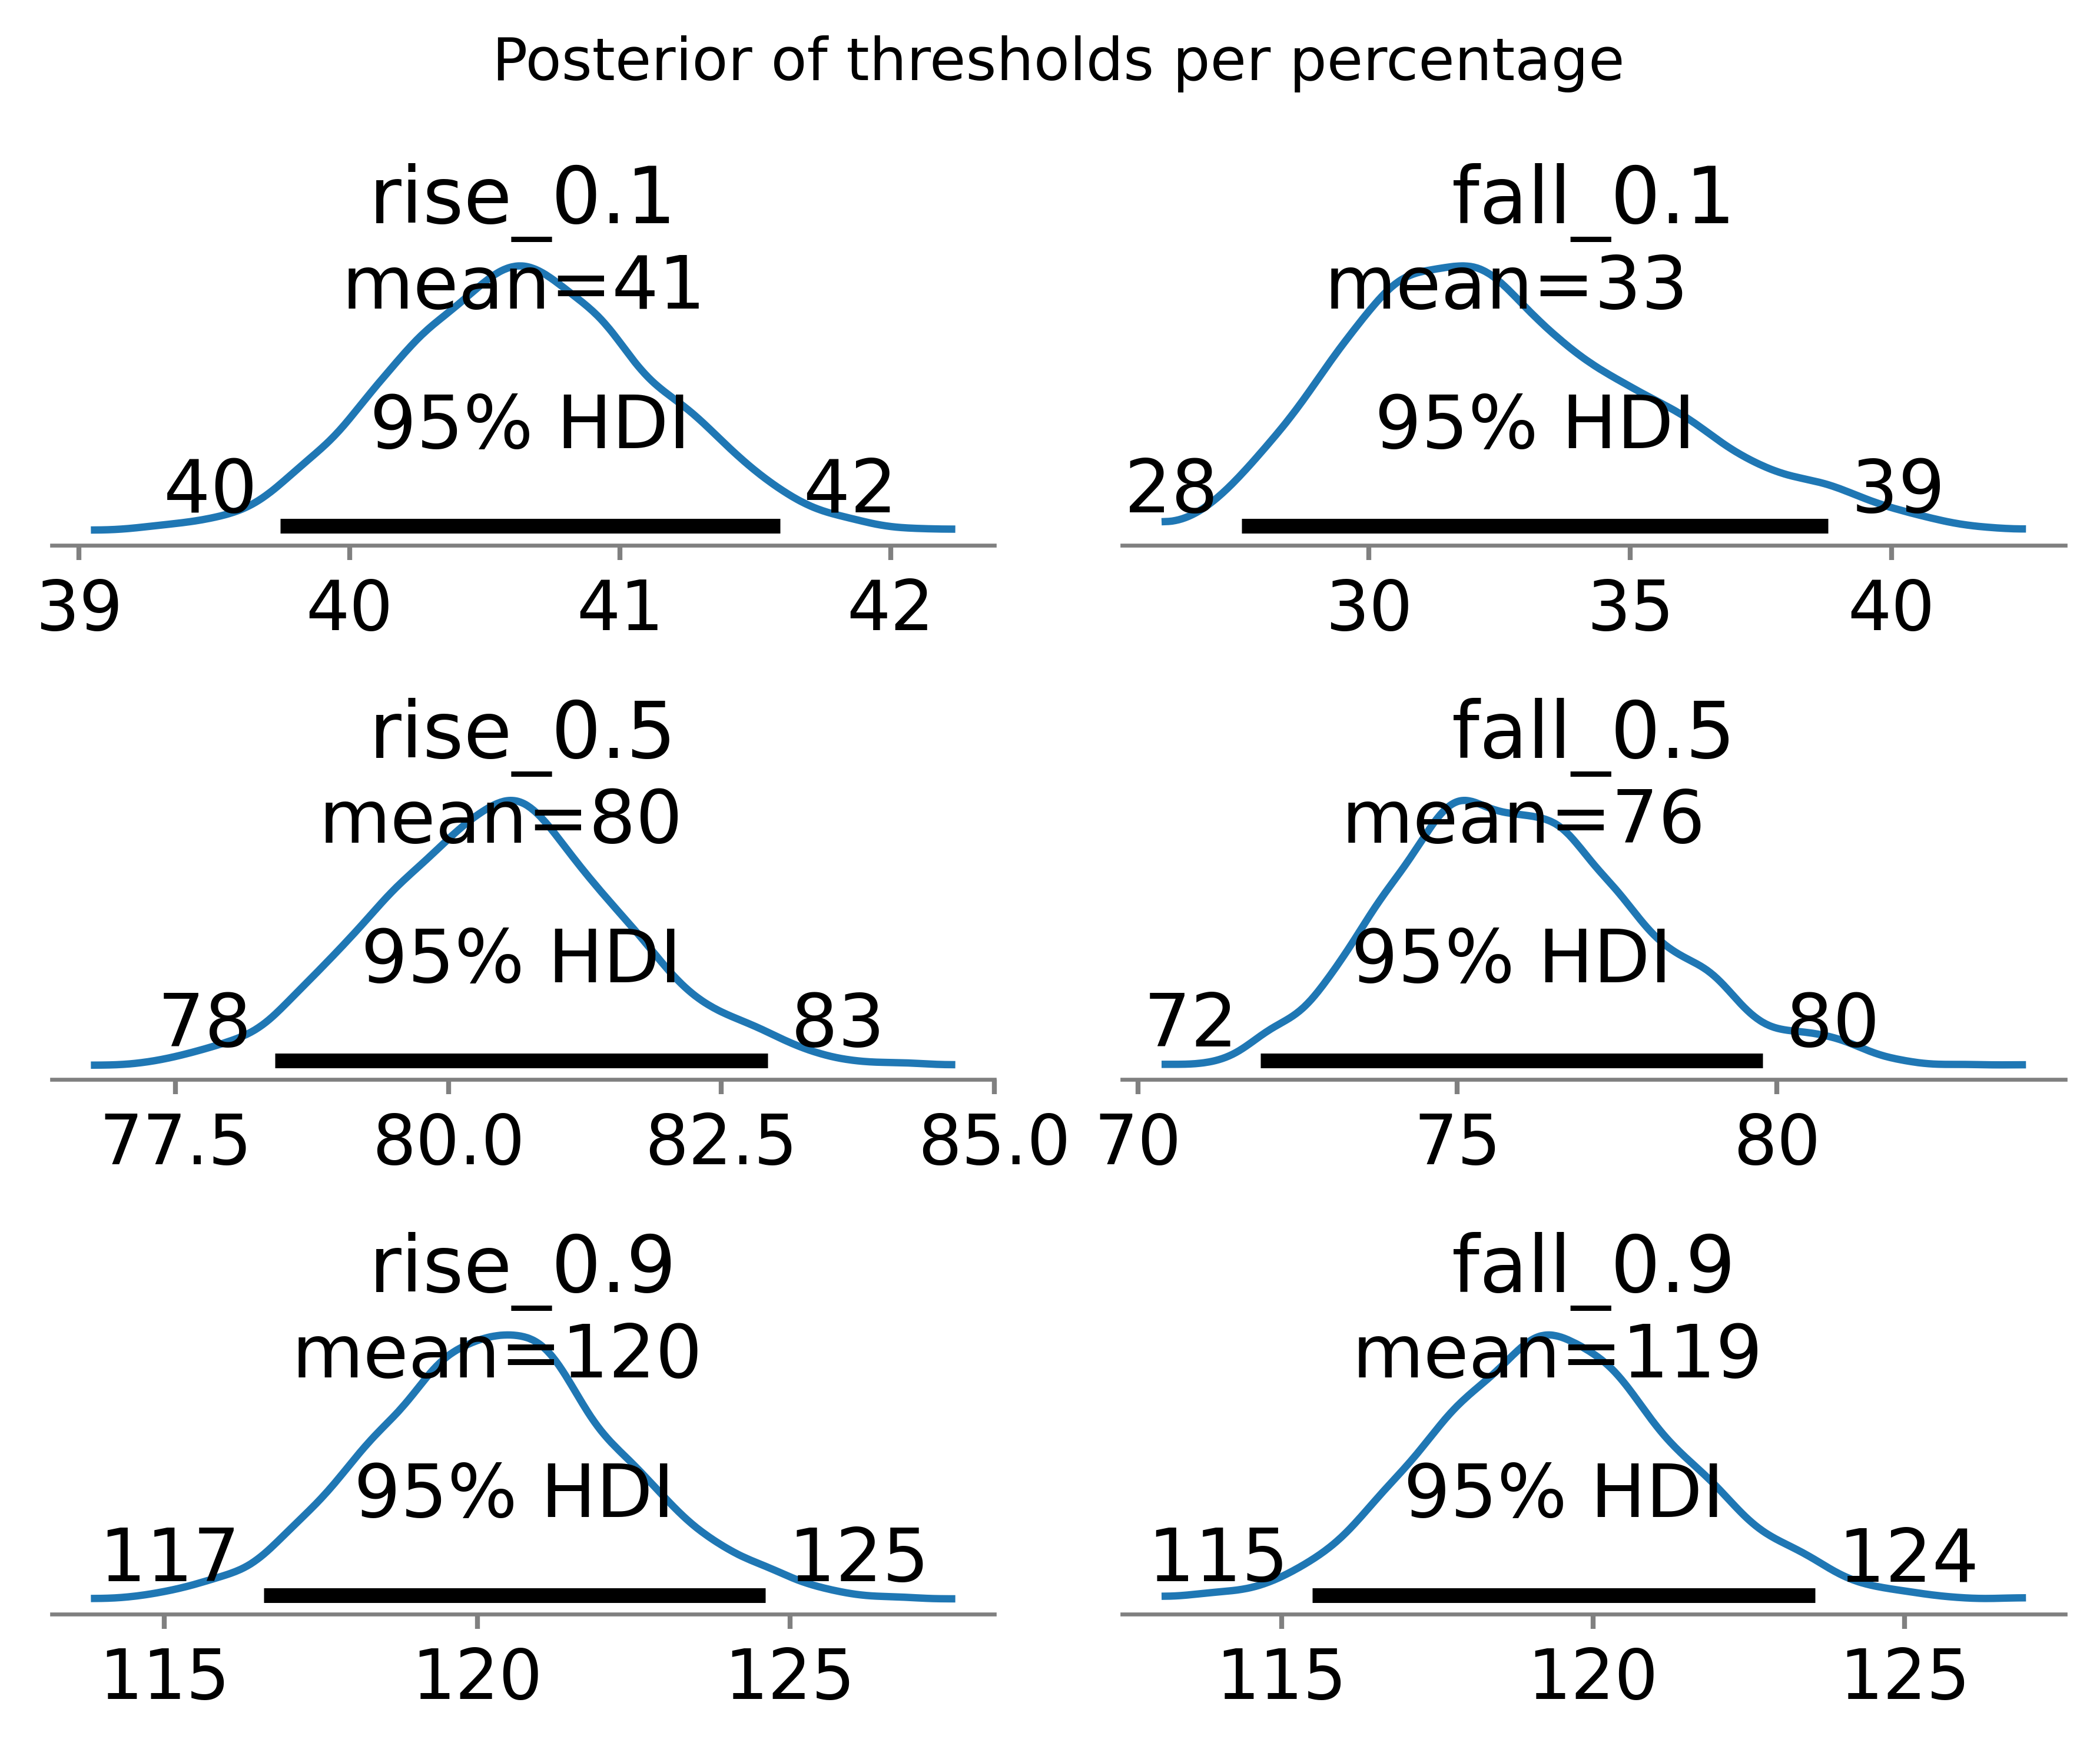

Summary (mean, median, 95% HDI):

                          mean      sd  hdi_1.5%  hdi_98.5%  mcse_mean  \
Time to rise to 10.0%   -1.679   0.082    -1.861     -1.513      0.001   
Time to fall to 10.0%  221.959  15.834   183.612    248.784      0.358   

                       mcse_sd  ess_bulk  ess_tail  r_hat  
Time to rise to 10.0%    0.001    3038.0    3062.0    1.0  
Time to fall to 10.0%    0.253    2058.0    2119.0    1.0  

Explicit numeric results:
Rise to 0.1% - mean: -1.679, median: -1.677, 95% HDI: [-1.861, -1.513]
Fall to 0.1% - mean: 221.959, median: 224.788, 95% HDI: [183.612, 248.784]
Summary (mean, median, 95% HDI):

                         mean     sd  hdi_1.5%  hdi_98.5%  mcse_mean  mcse_sd  \
Time to rise to 50.0%  -0.628  0.028    -0.693     -0.570      0.000    0.000   
Time to fall to 50.0%  15.392  3.086     9.373     22.433      0.068    0.048   

                       ess_bulk  ess_tail  r_hat  
Time to rise to 50.0%    3311.0    3242.0    1.0  
Time to fa

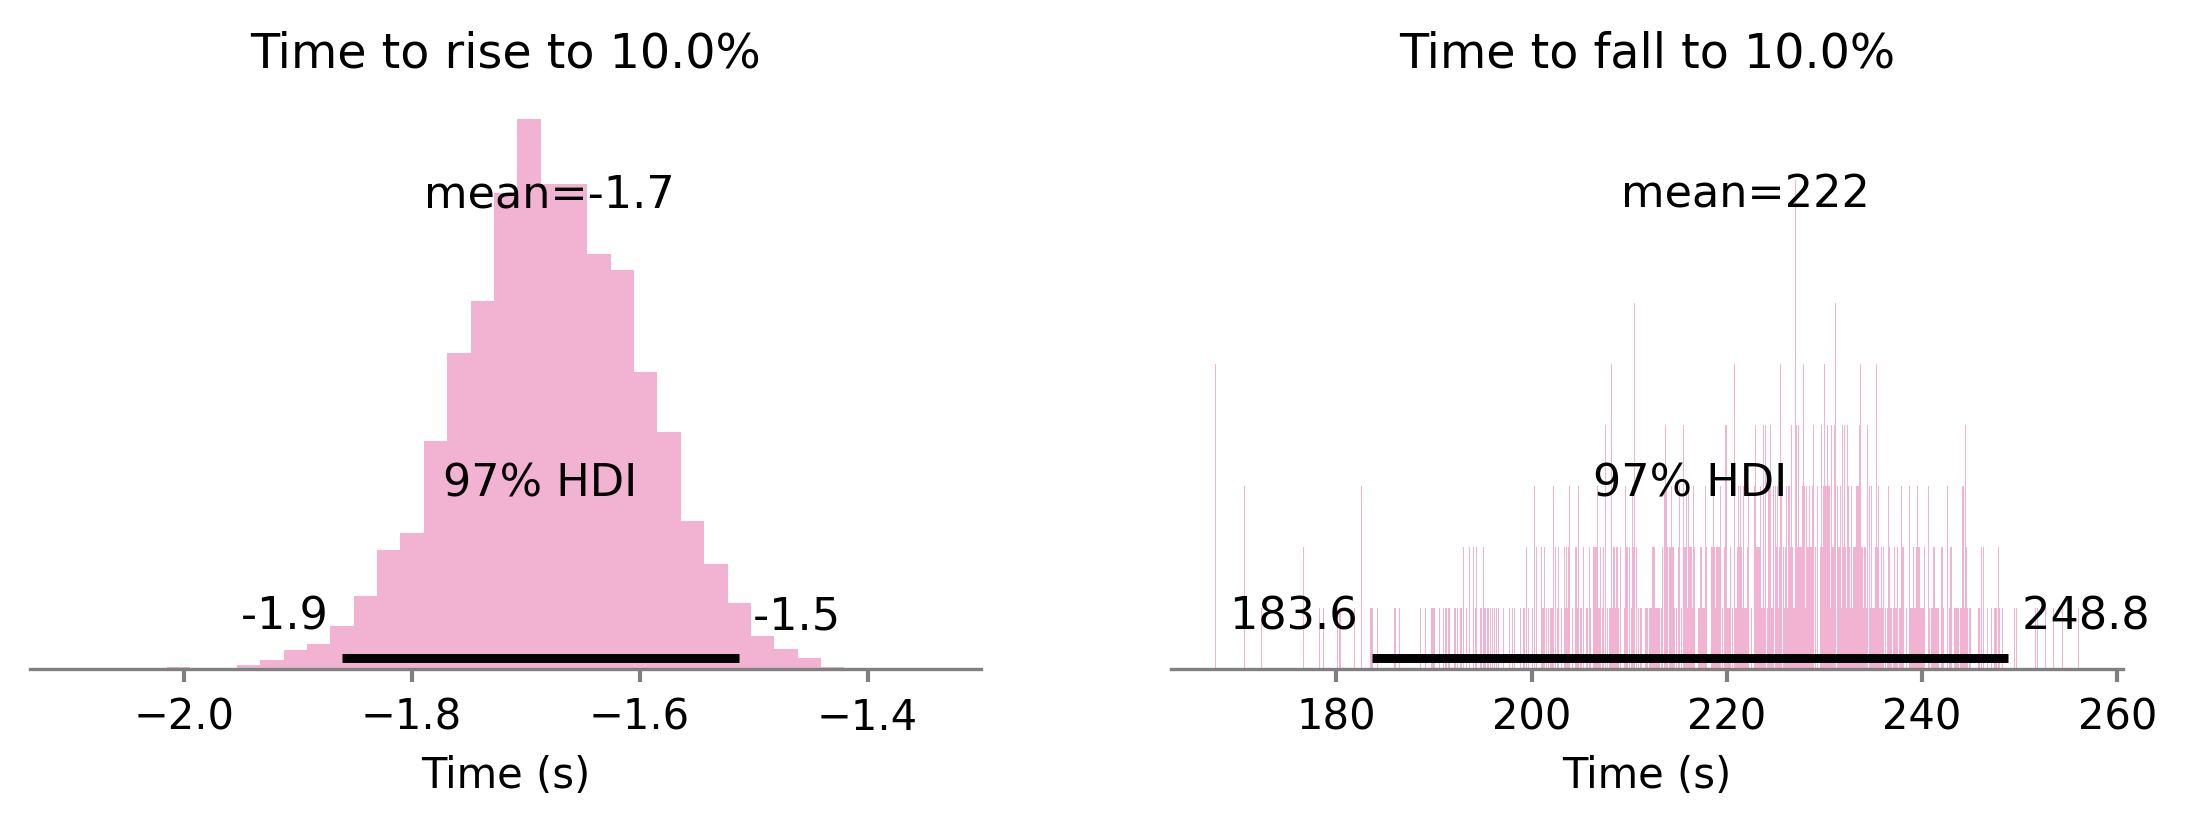

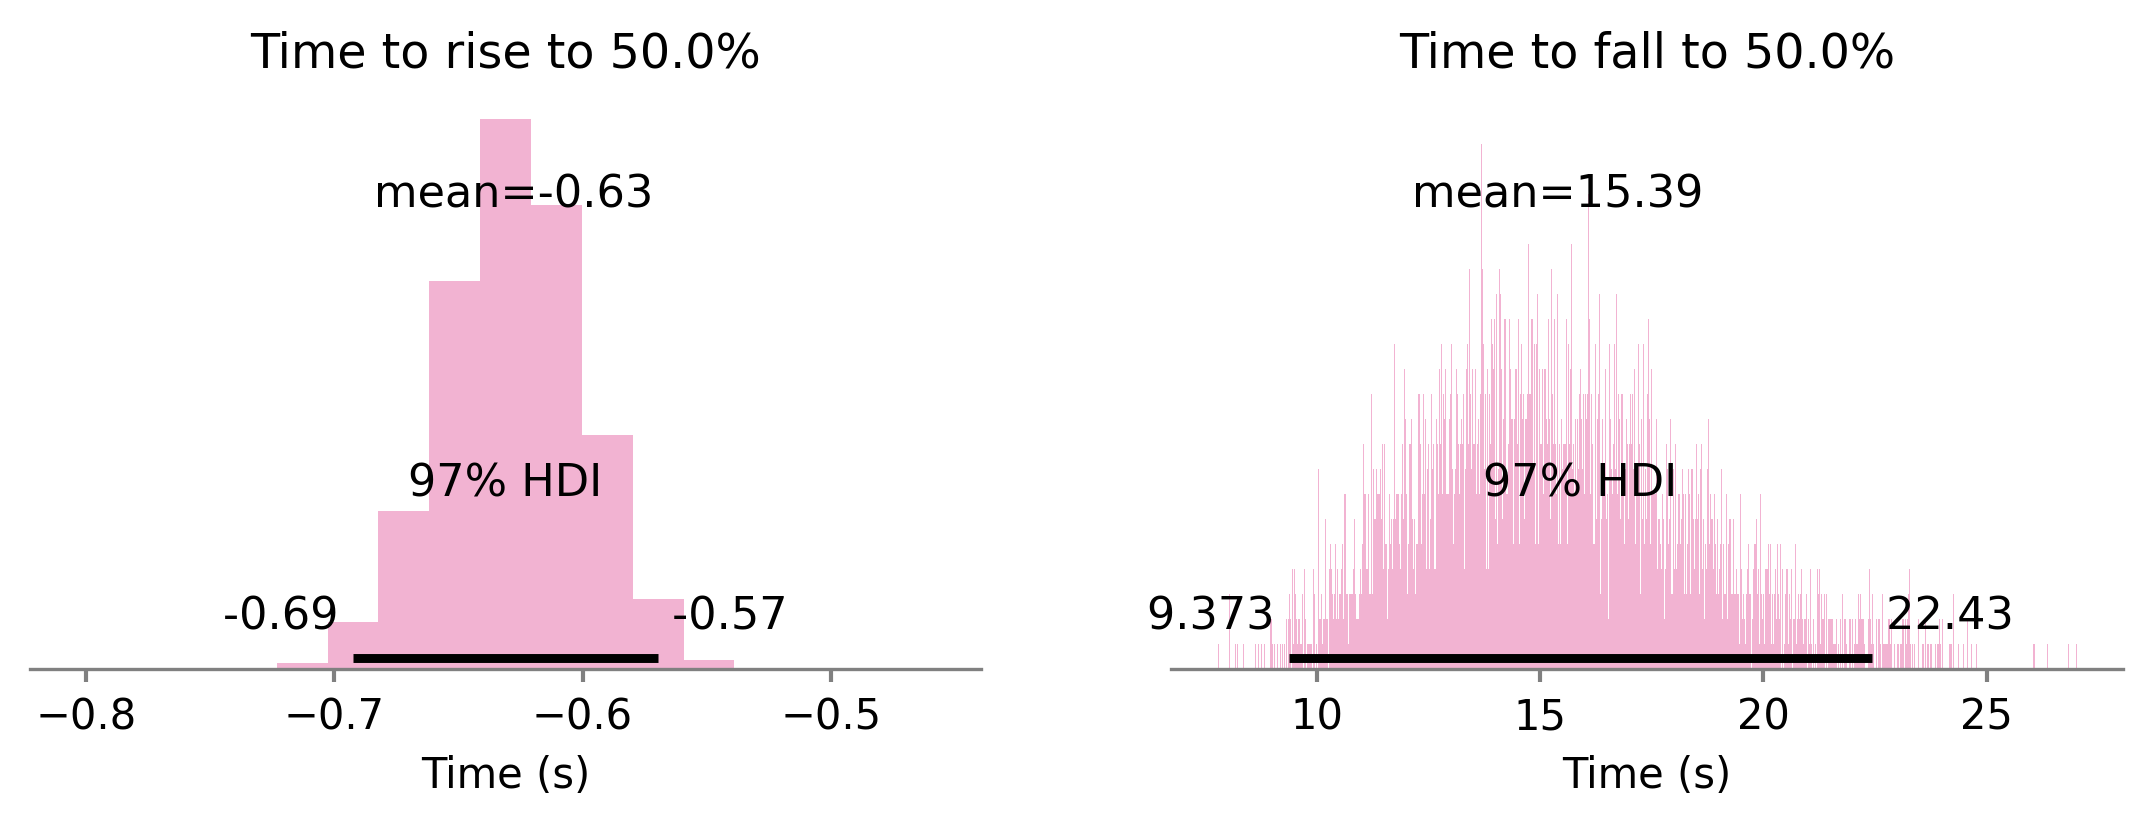

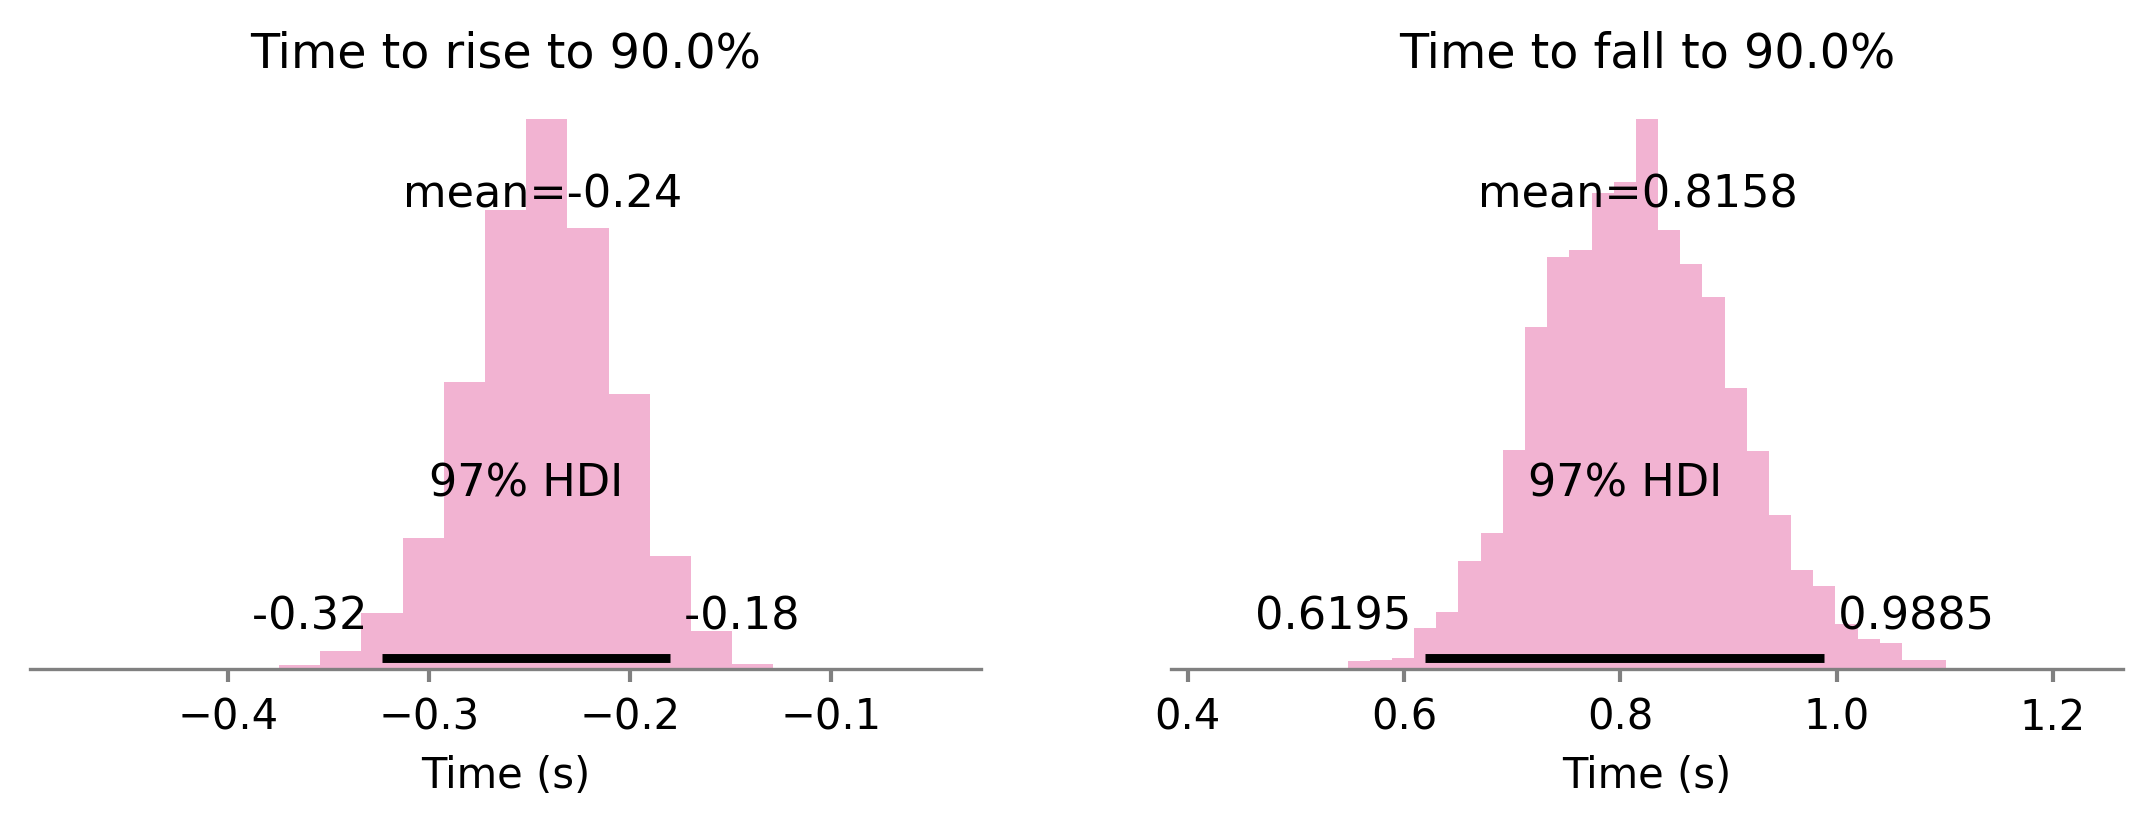

In [21]:
calculate_rate_percentages_of_peak(idata_predictions.predictions,X_test,cell_type='ON')

In [22]:

# Extract posterior lambda and summarize
lambda_preds = idata_predictions.predictions['rate']
lambda_mean = lambda_preds.mean(("chain","draw"))
# lambda_mean

count_preds = idata_predictions.predictions['count_pred_new']
count_pred_mean = count_preds.mean(("chain","draw"))
count_pred_upper = count_preds.quantile(0.975,("chain","draw"))
count_pred_lower = count_preds.quantile(0.025,("chain","draw"))

In [23]:
preds_numpy = count_preds.to_numpy()
print(preds_numpy.shape)
preds_numpy = preds_numpy.T.reshape((X_test.shape[0],-1))
preds_numpy.shape

(4, 1000, 20000)


(20000, 4000)

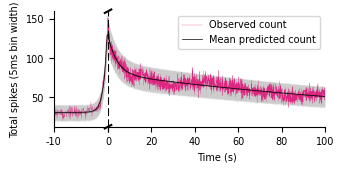

In [24]:
plot_predictions_paper(counts,X_test,count_pred_mean,lambda_preds,lambda_mean,preds_numpy, cell_name="ON",
                       filename="18_switching_model_ON_cells_double_exp_aggregated",
                   basePath=base_path,save=True)

## Store the model predictions for important quantities

In [25]:
prediction_save_path: Path = Path("./models/on_models/18_double_exponential_aggregated_counts/ON_model_double_exp_mean_predictions")

data = {
    "counts":counts ,
    "X_test":X_test ,
    "count_pred_mean":count_pred_mean ,
    "lambda_preds":lambda_preds ,
    "lambda_mean":lambda_mean ,
    "preds_numpy":preds_numpy,
    "t_switch": idata.posterior['t_switch']

}

store_model_predictions(prediction_save_path,data)